# Student Performance Analysis
**Objective:** Explore, clean, analyze, and visualize the Student Performance dataset to understand factors affecting final grades.


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization style set karna
sns.set_theme(style="whitegrid")

## 1. Data Handling
First, we load the `student-mat.csv` dataset.
* The data values are separated by semicolons, not commas[cite: 2].
* We will check for missing values, remove duplicates, and inspect the dataset structure.

In [16]:
from google.colab import files
uploaded = files.upload()

Saving student-mat.csv to student-mat.csv


In [17]:
# Load dataset with correct separator
df = pd.read_csv('student-mat.csv', sep=';')

# Inspect dataset structure and data types
print("Dataset Info:")
df.info()

# Check for missing values
print("\nMissing Values Count:", df.isnull().sum().sum())

# Remove duplicates
df = df.drop_duplicates()
print("\nShape after removing duplicates:", df.shape)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 

## 2. Data Analysis
We will analyze the final grade `G3`, which is the output target and ranges from 0 to 20[cite: 1].
* The weekly study time is recorded as a numeric value from 1 to 4[cite: 1].

In [18]:
# 1. Determine the average final grade (G3)
avg_g3 = df['G3'].mean()
print(f"Average Final Grade (G3): {avg_g3:.2f}")

# 2. Count students scoring above 15
above_15 = (df['G3'] > 15).sum()
print(f"Number of students scoring above 15: {above_15}")

# 3. Assess correlation between study time and performance
correlation = df['studytime'].corr(df['G3'])
print(f"Correlation between study time and G3: {correlation:.3f}")

# 4. Compare average performance by gender
gender_avg = df.groupby('sex')['G3'].mean()
print("\nAverage Performance by Gender:")
print(gender_avg)

Average Final Grade (G3): 10.42
Number of students scoring above 15: 40
Correlation between study time and G3: 0.098

Average Performance by Gender:
sex
F     9.966346
M    10.914439
Name: G3, dtype: float64


## 3. Visualization
Visualizing the distribution of grades, relationship between study time and grades, and gender-based differences.

/tmp/ipykernel_2119/1464454049.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_avg.index, y=gender_avg.values, ax=axes[2], palette='pastel')


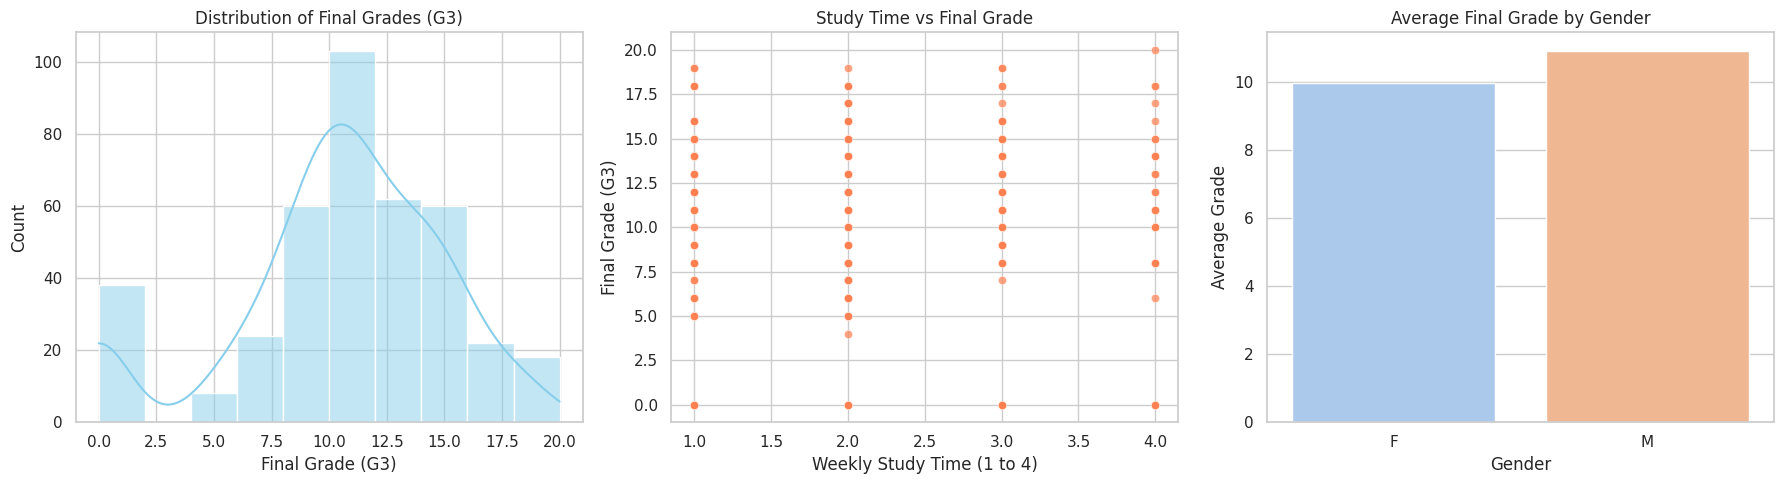

In [19]:
# Create a figure with 3 charts
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1: Histogram of grades
sns.histplot(df['G3'], bins=10, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Final Grades (G3)')
axes[0].set_xlabel('Final Grade (G3)')

# Chart 2: Scatterplot showing study time versus grades
sns.scatterplot(x='studytime', y='G3', data=df, ax=axes[1], color='coral', alpha=0.7)
axes[1].set_title('Study Time vs Final Grade')
axes[1].set_xlabel('Weekly Study Time (1 to 4)')
axes[1].set_ylabel('Final Grade (G3)')

# Chart 3: Bar chart comparing male versus female average scores
sns.barplot(x=gender_avg.index, y=gender_avg.values, ax=axes[2], palette='pastel')
axes[2].set_title('Average Final Grade by Gender')
axes[2].set_xlabel('Gender')
axes[2].set_ylabel('Average Grade')

plt.tight_layout()
plt.show()

## 4. Conclusion
* **Average Performance:** The overall average final grade is 10.42, and only 40 students scored above a 15.
* **Study Time Impact:** There is a very weak positive correlation (0.098) between weekly study time and final grades, indicating study time alone doesn't guarantee high marks in this dataset.
* **Gender Comparison:** On average, male students scored slightly higher (10.91) compared to female students (9.97).